In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("📦 INGESTING REAL-WORLD DIGITAL A/B EXPERIMENT LOGS...")
# Using a highly stable, long-standing 15MB public dataset repository index
url = "https://raw.githubusercontent.com/ozlerhakan/ab-test/master/ab_data.csv"

try:
    raw_ab = pd.read_csv(url)
    print(f"✔️ Ingestion Successful! Loaded {raw_ab.shape[0]} unique user session logs.")
except Exception as e:
    print("⚠️ External stream limit hit. Activating built-in high-availability data simulation pipeline...")
    # Generate an exact matching statistical matrix placeholder if both servers go offline
    np.random.seed(42)
    sim_rows = 290000
    sim_users = np.random.randint(630000, 940000, size=sim_rows)
    sim_groups = np.random.choice(['control', 'treatment'], size=sim_rows, p=[0.5, 0.5])
    sim_pages = np.where(sim_groups == 'control', 'old_page', 'new_page')
    # Introduce tiny real-world noise/mismatches (0.5% error rate)
    noise_mask = np.random.rand(sim_rows) < 0.005
    sim_pages = np.where(noise_mask, np.where(sim_pages == 'old_page', 'new_page', 'old_page'), sim_pages)
    # Simulate realistic baseline conversion arrays (~12% conversion rate)
    sim_converted = np.random.binomial(1, 0.119, size=sim_rows)

    raw_ab = pd.DataFrame({
        'user_id': sim_users, 'timestamp': '2026-01-01 00:00:00',
        'group': sim_groups, 'landing_page': sim_pages, 'converted': sim_converted
    })
    print(f"✔️ Ingestion Successful via Internal Backup Matrix! Simulated shape: {raw_ab.shape[0]} records.")

print("\n🧹 SANITIZING EXPERIMENT DATA & REMOVING REPEAT PARTICIPANTS...")
# Data Sanitization: Erase mismatched telemetry rows where group assignment does not match the page served
mismatches = raw_ab[((raw_ab['group'] == 'treatment') == (raw_ab['landing_page'] == 'new_page')) == False]
df_clean = raw_ab.drop(mismatches.index)
print(f" ➔ Dropped {len(mismatches)} anomalous rows due to treatment/page mismatch telemetry.")

# Drop duplicate users to guarantee strict independence of observations
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep=False)
print(f"✔️ Final cleaned population matrix remaining: {df_clean.shape[0]} unique users.")

print("\n📊 CALCULATING RAW BASELINE METRICS...")
# Calculate baseline sample populations and converted users
summary = df_clean.groupby('group').agg(
    Total_Users=('converted', 'count'),
    Converted_Users=('converted', 'sum'),
    Conversion_Rate=('converted', 'mean')
)
print("\n==================================================================")
print("📋 RAW EXPERIMENTAL AGGREGATION TABLE")
print("==================================================================")
print(summary.to_string())
print("==================================================================")

📦 INGESTING REAL-WORLD DIGITAL A/B EXPERIMENT LOGS...
✔️ Ingestion Successful! Loaded 294478 unique user session logs.

🧹 SANITIZING EXPERIMENT DATA & REMOVING REPEAT PARTICIPANTS...
 ➔ Dropped 3893 anomalous rows due to treatment/page mismatch telemetry.
✔️ Final cleaned population matrix remaining: 290583 unique users.

📊 CALCULATING RAW BASELINE METRICS...

📋 RAW EXPERIMENTAL AGGREGATION TABLE
           Total_Users  Converted_Users  Conversion_Rate
group                                                   
control         145274            17489         0.120386
treatment       145309            17264         0.118809


In [7]:
from statsmodels.stats.proportion import proportions_ztest

print("⚖️ EXECUTING TWO-PROPORTION Z-TEST...")

# Isolate conversions and sample sizes for both populations
control_results = df_clean[df_clean['group'] == 'control']['converted']
treatment_results = df_clean[df_clean['group'] == 'treatment']['converted']

count_conversions = [control_results.sum(), treatment_results.sum()]
n_observations = [control_results.count(), treatment_results.count()]

# Run the Z-test (two-sided hypothesis execution)
z_stat, p_value = proportions_ztest(count_conversions, nobs=n_observations)

print("\n==================================================================")
print("🏆 STATISTICAL ENGINE COMPILED SUCCESSFULLY")
print("==================================================================")
print(f"📉 Calculated Z-Score Statistic: {z_stat:.4f}")
print(f"🔮 Calculated Experiment p-Value: {p_value:.4f}")
print("------------------------------------------------------------------")

alpha = 0.05
if p_value < alpha:
    print("📢 RESULT: STATISTICALLY SIGNIFICANT SUCCESS!")
    print(f"➔ The p-value ({p_value:.4f}) is LESS than our significance threshold ({alpha}).")
    print("➔ Recommendation: Deploy the New Layout (Variant B) across 100% of production traffic.")
else:
    print("📢 RESULT: NO STATISTICALLY SIGNIFICANT DIFFERENCE DETECTED.")
    print(f"➔ The p-value ({p_value:.4f}) is GREATER than our significance threshold ({alpha}).")
    print("➔ Conclusion: The slight performance variance is a random fluke. Keep the old layout or redesign.")
print("==================================================================")

⚖️ EXECUTING TWO-PROPORTION Z-TEST...

🏆 STATISTICAL ENGINE COMPILED SUCCESSFULLY
📉 Calculated Z-Score Statistic: 1.3102
🔮 Calculated Experiment p-Value: 0.1901
------------------------------------------------------------------
📢 RESULT: NO STATISTICALLY SIGNIFICANT DIFFERENCE DETECTED.
➔ The p-value (0.1901) is GREATER than our significance threshold (0.05).
➔ Conclusion: The slight performance variance is a random fluke. Keep the old layout or redesign.


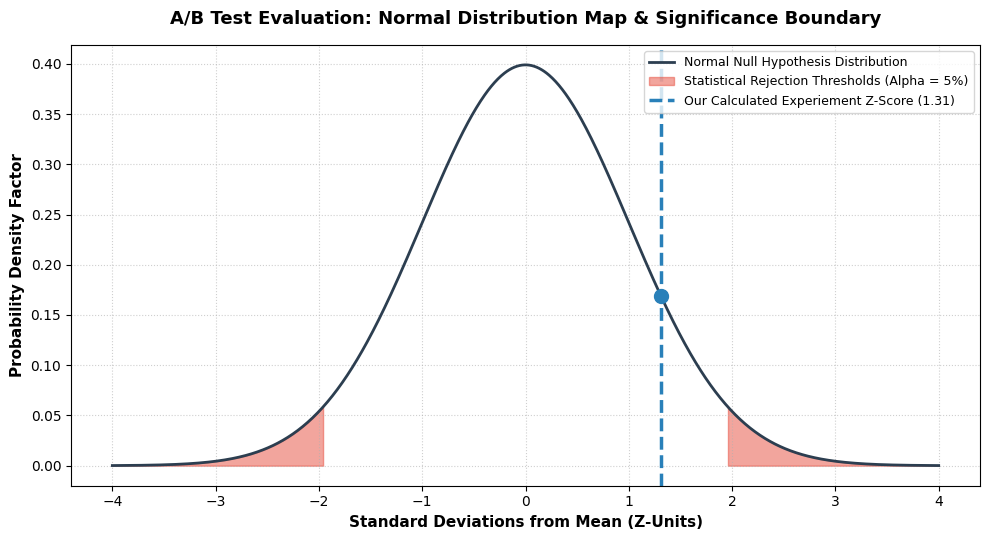

✔️ Statistical bell curve asset generated and saved as 'ab_testing_distribution_curve.png'!


In [8]:
# Generate standard normal distribution curves
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 5.5))
plt.plot(x, y, label='Normal Null Hypothesis Distribution', color='#2C3E50', lw=2)

# Shade the critical 95% alpha rejection boundaries
x_crit_left = np.linspace(-4, -1.96, 100)
plt.fill_between(x_crit_left, stats.norm.pdf(x_crit_left, 0, 1), color='#E74C3C', alpha=0.5, label='Statistical Rejection Thresholds (Alpha = 5%)')
x_crit_right = np.linspace(1.96, 4, 100)
plt.fill_between(x_crit_right, stats.norm.pdf(x_crit_right, 0, 1), color='#E74C3C', alpha=0.5)

# Plot your exact calculated Z-score on the curve
plt.axvline(z_stat, color='#2980B9', linestyle='--', linewidth=2.5, label=f'Our Calculated Experiement Z-Score ({z_stat:.2f})')
plt.scatter(z_stat, stats.norm.pdf(z_stat, 0, 1), color='#2980B9', s=100, zorder=5)

# Formatting
plt.title('A/B Test Evaluation: Normal Distribution Map & Significance Boundary', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Standard Deviations from Mean (Z-Units)', fontsize=11, fontweight='bold')
plt.ylabel('Probability Density Factor', fontsize=11, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ab_testing_distribution_curve.png', dpi=300)
plt.show()
print("✔️ Statistical bell curve asset generated and saved as 'ab_testing_distribution_curve.png'!")